In [ ]:
  from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Adjust the path if your files are elsewhere!
# !unzip /content/drive/MyDrive/yelp_70k/yelp_70k.zip -d /content/drive/MyDrive/yelp_70k/images/

In [ ]:
import pandas as pd
import os

# Set your CSV and image folder paths
csv_path = '/content/drive/MyDrive/yelp_70k/yelp_70k_metadata.csv'
image_folder = '/content/drive/MyDrive/yelp_70k/images/yelp_70k/'

# ---- Load Metadata and Build file_path ----
df = pd.read_csv(csv_path)
df['file_path'] = image_folder + df['photo_id'] + '.jpg'

In [ ]:
# ---- Keep Only Valid Images (Present AND Usable) ----
from PIL import Image

def is_valid_image(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except Exception:
        return False

print(f"Before filtering: {len(df)} samples")
df['valid'] = df['file_path'].apply(is_valid_image)
df = df[df['valid']].copy().drop(columns=['valid'])
print(f"After filtering: {len(df)} valid images remain")

Before filtering: 70000 samples
After filtering: 69964 valid images remain


#### SPlit into Train/val/test

In [ ]:
# ---- Encode Labels & Stratified Split ----
from sklearn.model_selection import train_test_split

target_labels = ['food', 'inside', 'outside', 'drink']
df['label_idx'] = df['label'].map({l:i for i,l in enumerate(target_labels)})

train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df['label_idx'],
    random_state=42,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    stratify=train_val_df['label_idx'],
    random_state=42,
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("Train class distribution:\n", train_df['label'].value_counts())

print("Class distribution (percent):\n", (train_df['label'].value_counts(normalize=True) * 100).round(2))


Train: 48972, Val: 10497, Test: 10495
Train class distribution:
 label
food       26599
inside     13804
outside     4634
drink       3935
Name: count, dtype: int64
Class distribution (percent):
 label
food       54.31
inside     28.19
outside     9.46
drink       8.04
Name: proportion, dtype: float64


In [ ]:
# ---- Build Data Pipelines with Class Balance for Training ----
import tensorflow as tf
import numpy as np
from collections import defaultdict

IMG_SIZE = 64
BATCH_SIZE = 64
class_names = target_labels
NUM_CLASSES = 4
class2idx = {name: i for i, name in enumerate(class_names)}

def get_paths_labels(df):
    return df['file_path'].tolist(), df['label'].map(class2idx).tolist()

train_paths, train_labels = get_paths_labels(train_df)
val_paths, val_labels = get_paths_labels(val_df)
test_paths, test_labels = get_paths_labels(test_df)

def preprocess_image(file_path, label, augment=False):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = (tf.cast(image, tf.float32) / 127.5) - 1.0
    if augment:
        image = tf.image.random_flip_left_right(image)
    return image, label

def make_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths), seed=42) if augment else ds
    ds = ds.map(lambda x, y: preprocess_image(x, y, augment=augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds = make_dataset(val_paths, val_labels, augment=False)
test_ds = make_dataset(test_paths, test_labels, augment=False)

# ---- Balanced batch generator for training ----
paths_by_class = defaultdict(list)
for path, label in zip(train_paths, train_labels):
    paths_by_class[label].append(path)
min_class_count = min([len(paths) for paths in paths_by_class.values()])
print("Samples per class (for balanced training):", min_class_count)

def balanced_sample_paths_labels(paths_by_class, samples_per_class):
    sampled_paths, sampled_labels = [], []
    for class_idx, paths in paths_by_class.items():
        sampled = np.random.choice(paths, samples_per_class, replace=(len(paths) < samples_per_class))
        sampled_paths.extend(sampled)
        sampled_labels.extend([class_idx]*samples_per_class)
    combined = list(zip(sampled_paths, sampled_labels))
    np.random.shuffle(combined)
    shuffled_paths, shuffled_labels = zip(*combined)
    return list(shuffled_paths), list(shuffled_labels)

def make_balanced_train_ds(paths_by_class, samples_per_class, batch_size=BATCH_SIZE):
    def generator():
        paths, labels = balanced_sample_paths_labels(paths_by_class, samples_per_class)
        for p, l in zip(paths, labels):
            yield p, l
    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.string),
            tf.TensorSpec(shape=(), dtype=tf.int32),
        )
    )
    ds = ds.map(lambda x, y: preprocess_image(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

balanced_train_ds = make_balanced_train_ds(paths_by_class, min_class_count)

# Check one batch for sanity
for images, labels in balanced_train_ds.take(1):
    print("Batch label distribution:", np.bincount(labels.numpy()))


Samples per class (for balanced training): 3935
Batch label distribution: [15 20 13 16]


In [ ]:
# ---- Save Splits for Reproducibility  ----
train_df.to_csv('/content/drive/MyDrive/yelp_70k/train_split.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/yelp_70k/val_split.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/yelp_70k/test_split.csv', index=False)


## WGAN MODEL

#### Generator

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

NOISE_DIM = 100

def build_generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES, img_shape=(IMG_SIZE, IMG_SIZE, 3)):
    noise_input = layers.Input(shape=(noise_dim,))
    label_input = layers.Input(shape=(), dtype='int32')
    label_embedding = layers.Embedding(num_classes, noise_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    x = layers.Concatenate()([noise_input, label_embedding])
    x = layers.Dense(8*8*256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((8,8,256))(x)
    x = layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(32, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(3, 5, strides=1, padding='same', activation='tanh')(x)
    return tf.keras.Model([noise_input, label_input], x, name="Generator")
generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100)       │        400 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 100)       │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 200)       │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16384)     │  3,276,800 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16384)     │     65,536 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 16384)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 8, 8, 256) │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 16, 16,    │    819,200 │ reshape_2[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 32, 32,    │    204,800 │ re_lu_5[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 64, 64,    │     51,200 │ re_lu_6[0][0]     │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                 

 Total params: 4,421,235 (16.87 MB)

 Trainable params: 4,388,019 (16.74 MB)

 Non-trainable params: 33,216 (129.75 KB)

#### Discriminator

In [ ]:
def build_critic(img_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    img_input = layers.Input(shape=img_shape)
    label_input = layers.Input(shape=(), dtype='int32')
    label_embedding = layers.Embedding(num_classes, np.prod(img_shape[:2]))(label_input)
    label_embedding = layers.Dense(img_shape[0] * img_shape[1])(label_embedding)
    label_embedding = layers.Reshape((img_shape[0], img_shape[1], 1))(label_embedding)
    x = layers.Concatenate(axis=-1)([img_input, label_embedding])
    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(512, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Flatten()(x)
    out = layers.Dense(1)(x)
    return tf.keras.Model([img_input, label_input], out, name="Critic")
critic = build_critic()
critic.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 4096)      │     16,384 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4096)      │ 16,781,312 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 64, 64, 1) │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64, 4) │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      6,464 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    204,928 │ leaky_re_lu_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 256) │    819,456 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 8, 8, 256) │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 4, 4, 512) │  3,277,312 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 4, 4, 512) │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8192)      │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      8,193 │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,114,049 (80.54 MB)

 Trainable params: 21,114,049 (80.54 MB)

 Non-trainable params: 0 (0.00 B)

#### Set Up WGAN-GP Loss and Optimizers

In [ ]:
LAMBDA_GP = 10.0

def gradient_penalty(critic, real_images, fake_images, labels):
    batch_size = tf.shape(real_images)[0]
    alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
    interpolated = alpha * real_images + (1 - alpha) * fake_images
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        pred = critic([interpolated, labels], training=True)
    grads = gp_tape.gradient(pred, [interpolated])[0]
    grads_l2 = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3]))
    gp = tf.reduce_mean((grads_l2 - 1.0) ** 2)
    return gp

critic_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.0, beta_2=0.9)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.0, beta_2=0.9)


#### Training Loop

In [ ]:
EPOCHS = 5
N_CRITIC = 5

@tf.function
def train_critic_step(real_images, real_labels):
    real_batch_size = tf.shape(real_labels)[0]   # <--- FIXED
    noise = tf.random.normal([real_batch_size, NOISE_DIM])  # <--- FIXED
    fake_labels = real_labels
    with tf.GradientTape() as critic_tape:
        fake_images = generator([noise, fake_labels], training=True)
        real_output = critic([real_images, real_labels], training=True)
        fake_output = critic([fake_images, fake_labels], training=True)
        gp = gradient_penalty(critic, real_images, fake_images, real_labels)
        critic_loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output) + LAMBDA_GP * gp
    grads = critic_tape.gradient(critic_loss, critic.trainable_variables)
    critic_optimizer.apply_gradients(zip(grads, critic.trainable_variables))
    return critic_loss

@tf.function
def train_generator_step(labels):
    real_batch_size = tf.shape(labels)[0]    # <--- FIXED
    noise = tf.random.normal([real_batch_size, NOISE_DIM])  # <--- FIXED
    with tf.GradientTape() as gen_tape:
        fake_images = generator([noise, labels], training=True)
        fake_output = critic([fake_images, labels], training=True)
        generator_loss = -tf.reduce_mean(fake_output)
    grads = gen_tape.gradient(generator_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return generator_loss


In [ ]:
for epoch in range(EPOCHS):
    for real_images, real_labels in balanced_train_ds:
        for _ in range(N_CRITIC):
            critic_loss = train_critic_step(real_images, real_labels)
        generator_loss = train_generator_step(real_labels)
    print(f"Epoch {epoch+1}: Critic Loss: {critic_loss.numpy():.4f}, Gen Loss: {generator_loss.numpy():.4f}")


Epoch 1: Critic Loss: -20.8274, Gen Loss: -577.2908
Epoch 2: Critic Loss: -12.4345, Gen Loss: 56.1524
Epoch 3: Critic Loss: -10.4721, Gen Loss: -77.6496
Epoch 4: Critic Loss: -17.6868, Gen Loss: -67.3749
Epoch 5: Critic Loss: -12.4710, Gen Loss: -14.8678


## Monitoring

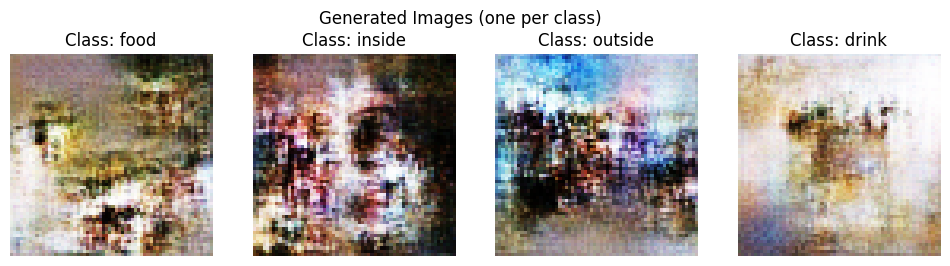

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def show_generated_images(generator, num_classes=4, noise_dim=100):
    generator.eval = False  # for Keras
    n_samples = num_classes
    noise = tf.random.normal([n_samples, noise_dim])
    labels = tf.constant(list(range(num_classes)), dtype=tf.int32)
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1.0) / 2.0  # [-1,1] -> [0,1] for display

    plt.figure(figsize=(12, 3))
    for i in range(n_samples):
        plt.subplot(1, n_samples, i+1)
        plt.imshow(generated_images[i].numpy())
        plt.title(f"Class: {class_names[labels[i]]}")
        plt.axis('off')
    plt.suptitle("Generated Images (one per class)")
    plt.show()

show_generated_images(generator, num_classes=NUM_CLASSES, noise_dim=NOISE_DIM)


#### Plot Losses Over Epochs

In [ ]:
critic_losses = []
generator_losses = []

for epoch in range(EPOCHS):
    for real_images, real_labels in balanced_train_ds:
        for _ in range(N_CRITIC):
            critic_loss = train_critic_step(real_images, real_labels)
        generator_loss = train_generator_step(real_labels)
    # Store epoch losses (convert to float for plotting)
    critic_losses.append(float(critic_loss.numpy()))
    generator_losses.append(float(generator_loss.numpy()))
    print(f"Epoch {epoch+1}: Critic Loss: {critic_losses[-1]:.4f}, Gen Loss: {generator_losses[-1]:.4f}")


Epoch 1: Critic Loss: -14.4982, Gen Loss: 16.6888
Epoch 2: Critic Loss: -13.0290, Gen Loss: -24.1012
Epoch 3: Critic Loss: -15.2115, Gen Loss: 141.0058
Epoch 4: Critic Loss: -13.9676, Gen Loss: -72.0681
Epoch 5: Critic Loss: -9.3894, Gen Loss: 80.3365


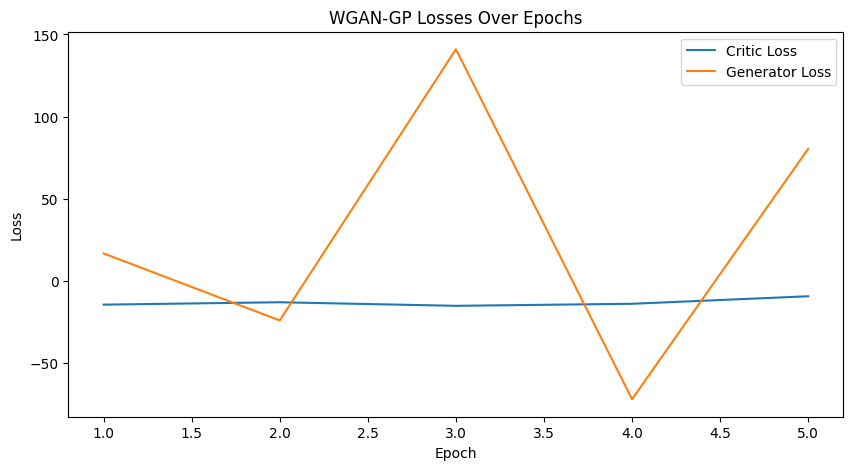

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(range(1, EPOCHS+1), critic_losses, label='Critic Loss')
plt.plot(range(1, EPOCHS+1), generator_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('WGAN-GP Losses Over Epochs')
plt.show()


Epoch 1: Critic Loss: -15.0639, Gen Loss: 152.3097


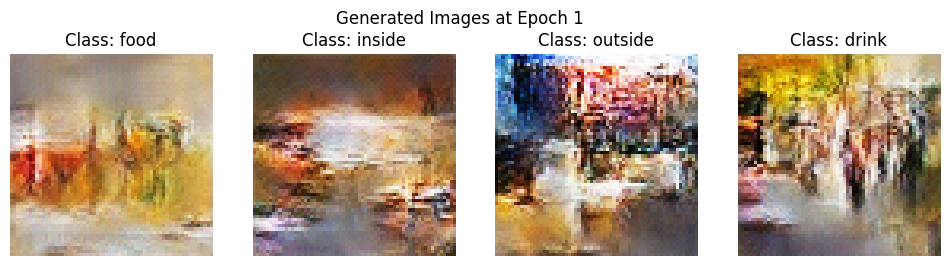

Epoch 2: Critic Loss: -11.8008, Gen Loss: 10.6843


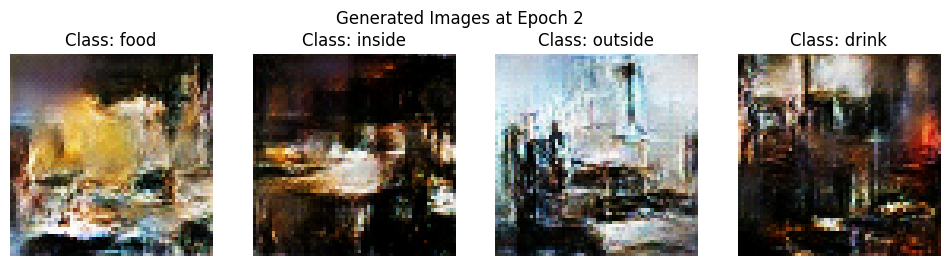

Epoch 3: Critic Loss: -13.8543, Gen Loss: -71.4155


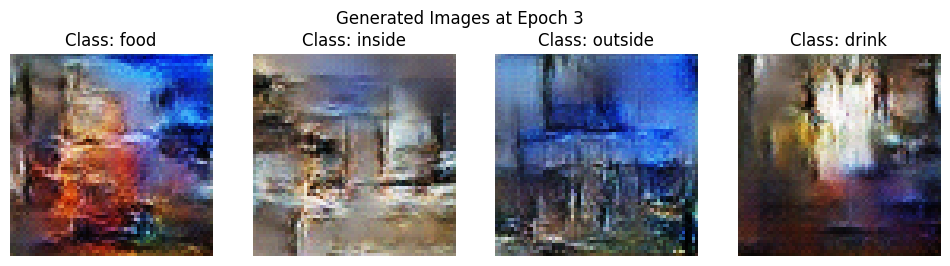

Epoch 4: Critic Loss: -11.8838, Gen Loss: 18.4199


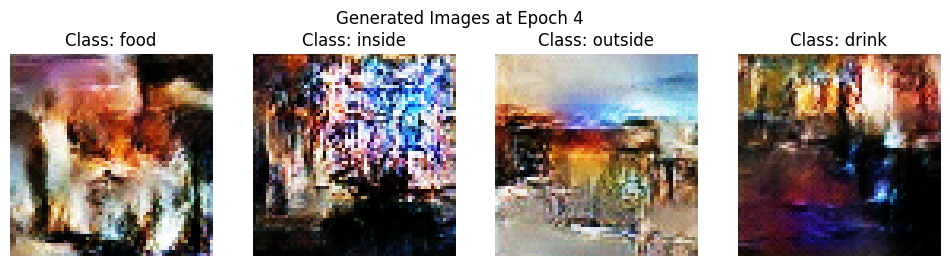

Epoch 5: Critic Loss: -12.3973, Gen Loss: -12.7308


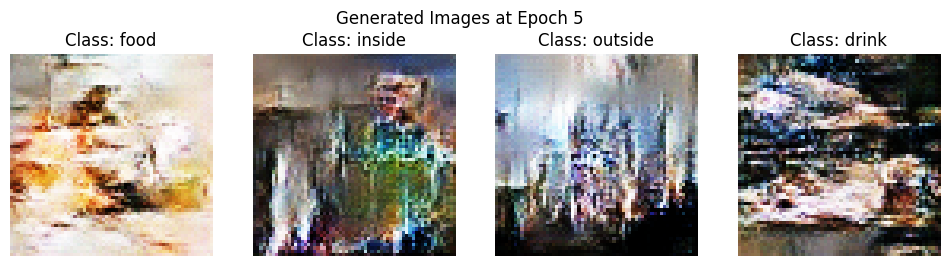

In [ ]:
def show_generated_images(generator, num_classes=4, noise_dim=100, epoch=0):
    noise = tf.random.normal([num_classes, noise_dim])
    labels = tf.constant(list(range(num_classes)), dtype=tf.int32)
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1.0) / 2.0  # [-1,1] -> [0,1] for display

    plt.figure(figsize=(12, 3))
    for i in range(num_classes):
        plt.subplot(1, num_classes, i+1)
        plt.imshow(generated_images[i].numpy())
        plt.title(f"Class: {class_names[labels[i]]}")
        plt.axis('off')
    plt.suptitle(f"Generated Images at Epoch {epoch+1}")
    plt.show()


for epoch in range(EPOCHS):
    for real_images, real_labels in balanced_train_ds:
        for _ in range(N_CRITIC):
            critic_loss = train_critic_step(real_images, real_labels)
        generator_loss = train_generator_step(real_labels)
    # Store epoch losses
    critic_losses.append(float(critic_loss.numpy()))
    generator_losses.append(float(generator_loss.numpy()))
    print(f"Epoch {epoch+1}: Critic Loss: {critic_losses[-1]:.4f}, Gen Loss: {generator_losses[-1]:.4f}")
    # Show generated images every epoch
    show_generated_images(generator, num_classes=NUM_CLASSES, noise_dim=NOISE_DIM, epoch=epoch)


## saving and exporting

#### Saving  model weights

In [ ]:
generator.save('/content/drive/MyDrive/yelp_70k/wgan_generator.h5')
critic.save('/content/drive/MyDrive/yelp_70k/wgan_critic.h5')


#### Save loss curves and trainig metrics

In [ ]:
import pickle

with open('/content/drive/MyDrive/yelp_70k/wgan_losses.pkl', 'wb') as f:
    pickle.dump({'critic_losses': critic_losses, 'generator_losses': generator_losses}, f)


In [ ]:
train_df.to_csv('/content/drive/MyDrive/yelp_70k/train_split.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/yelp_70k/val_split.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/yelp_70k/test_split.csv', index=False)


#### download

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/yelp_70k/wgan_generator.h5')
files.download('/content/drive/MyDrive/yelp_70k/wgan_critic.h5')
files.download('/content/drive/MyDrive/yelp_70k/wgan_losses.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Load

Constants and Class Mapping

In [ ]:
NUM_CLASSES = 4
NOISE_DIM = 100
IMG_SIZE = 64
class_names = ['food', 'inside', 'outside', 'drink']
class2idx = {name: i for i, name in enumerate(class_names)}


Mount Drive and load models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
generator = load_model('/content/drive/MyDrive/yelp_70k/wgan_generator.h5', compile=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Splits and Paths

In [ ]:
import pandas as pd
train_df = pd.read_csv('/content/drive/MyDrive/yelp_70k/train_split.csv')
val_df = pd.read_csv('/content/drive/MyDrive/yelp_70k/val_split.csv')
test_df = pd.read_csv('/content/drive/MyDrive/yelp_70k/test_split.csv')

def get_paths_labels(df):
    return df['file_path'].tolist(), df['label'].map(class2idx).tolist()

val_paths, val_labels = get_paths_labels(val_df)


## Model Evaluation

#### A. Inception Score (IS)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
import numpy as np
from scipy.stats import entropy


In [ ]:
NUM_GEN = 1000
BATCH_SIZE_IS = 100  # InceptionV3 prefers batches <=100 for memory

gen_labels = np.random.randint(0, NUM_CLASSES, size=NUM_GEN)
gen_noise = tf.random.normal([NUM_GEN, NOISE_DIM])
gen_labels_tf = tf.convert_to_tensor(gen_labels, dtype=tf.int32)
generated_images = generator([gen_noise, gen_labels_tf], training=False)
# Map from [-1,1] to [0,255] uint8 for InceptionV3
generated_images = ((generated_images + 1) * 127.5).numpy().astype(np.uint8)

In [ ]:
resized_gen = tf.image.resize(generated_images, (299,299)).numpy()


Get InceptionV3 Predictions

In [ ]:
inception = InceptionV3(include_top=True, weights='imagenet', pooling=None)
def get_inception_preds(imgs):
    imgs = preprocess_input(imgs.astype(np.float32))
    return inception.predict(imgs, batch_size=BATCH_SIZE_IS, verbose=1)



In [ ]:
gen_preds = get_inception_preds(resized_gen)

10/10 ━━━━━━━━━━━━━━━━━━━━ 293s 27s/step


 Compute Inception Score (IS)

In [ ]:
# Softmax outputs (class probabilities)
preds = gen_preds
split = 10  # Number of splits for IS
scores = []

N = preds.shape[0]
for i in range(split):
    part = preds[i * N // split: (i+1) * N // split, :]
    py = np.mean(part, axis=0)
    scores.append(np.exp(np.mean([entropy(p, py) for p in part])))
IS_mean, IS_std = np.mean(scores), np.std(scores)
print(f"Inception Score (IS): {IS_mean:.4f} ± {IS_std:.4f}")


Inception Score (IS): 3.3137 ± 0.1569


#### FID Calculation

In [ ]:
# Get Features for Real Validation Images
from tensorflow.keras.applications.inception_v3 import InceptionV3
from scipy.linalg import sqrtm

# Build InceptionV3 for features (pool3 layer)
incept_feat = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))

def get_features(images):
    # Preprocess and predict
    images = preprocess_input(images.astype(np.float32))
    feats = incept_feat.predict(images, batch_size=BATCH_SIZE_IS, verbose=1)
    return feats

# Prepare real (validation) images, matching NUM_GEN count
real_sample_idx = np.random.choice(len(val_paths), NUM_GEN, replace=False)
real_imgs = []
for idx in real_sample_idx:
    img = tf.io.read_file(val_paths[idx])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299,299))
    real_imgs.append(img)
real_imgs = tf.stack(real_imgs).numpy().astype(np.uint8)

# Get features
real_feats = get_features(real_imgs)
gen_feats = get_features(resized_gen)


10/10 ━━━━━━━━━━━━━━━━━━━━ 266s 26s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 268s 27s/step


In [ ]:
# Compute means and covariances
mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
mu2, sigma2 = gen_feats.mean(axis=0), np.cov(gen_feats, rowvar=False)
# Compute FID
fid = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2*sqrtm(sigma1 @ sigma2))
print(f"FID: {fid:.4f}")


FID: 278.8428-0.0000j


Results

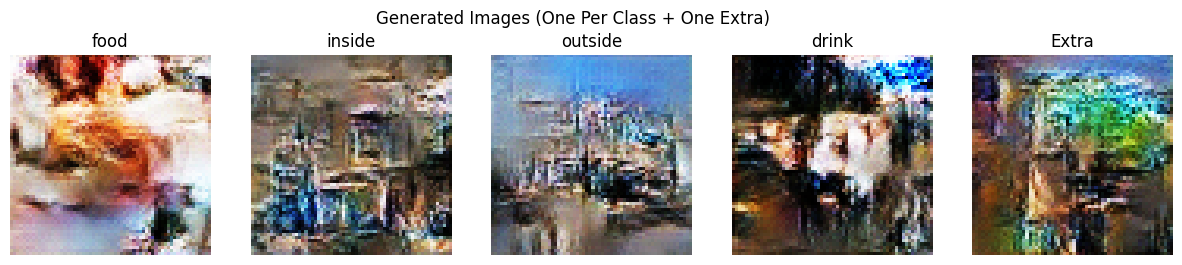

In [ ]:
def show_generated_images(generator, num_classes=4, noise_dim=100):
    n_samples = num_classes + 1
    noise = tf.random.normal([n_samples, noise_dim])
    labels = tf.constant([0,1,2,3, np.random.randint(0, num_classes)], dtype=tf.int32)
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1.0) / 2.0  # to [0,1] for display

    import matplotlib.pyplot as plt
    plt.figure(figsize=(15,3))
    for i in range(n_samples):
        plt.subplot(1, n_samples, i+1)
        plt.imshow(generated_images[i].numpy())
        if i < num_classes:
            plt.title(f"{class_names[labels[i]]}")
        else:
            plt.title("Extra")
        plt.axis('off')
    plt.suptitle("Generated Images (One Per Class + One Extra)")
    plt.show()

show_generated_images(generator, num_classes=NUM_CLASSES, noise_dim=NOISE_DIM)


## Model Evaluation: Inception Score (IS) and FID

**Inception Score (IS):**  
`3.31 ± 0.16`

**Fréchet Inception Distance (FID):**  
`278.84`

---

### **What do these scores mean?**

- The **Inception Score (IS)** tells us if our generated images are both diverse and clear. A score above 3 suggests the WGAN is making a variety of images, and the classes (food, inside, outside, drink) are somewhat recognizable, which is a good sign for the early stage of training. For comparison, real photos get much higher IS, but random images would be close to 1.

- The **FID** score checks how close our generated images are to real images. Lower numbers are better. Our FID of 278.8 is actually quite normal for first runs on real-world image data like Yelp photos. As the model trains longer and if we tweak settings, we’d expect this number to get lower.

---

### **Summary**

- These results are pretty normal at this point. The IS score shows we have some class variety, and FID will likely drop with more training.
- The sample images below also show that our generator is learning, though more tuning or training should help make them even clearer.
